In [1]:
# ─── CELL 1: Mount Google Drive ───────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive mounted successfully!")

Mounted at /content/drive
✅ Drive mounted successfully!


In [2]:
# ─── CELL 2: Install & Import All Libraries ────────────────────────────────────
import os
import random
import zipfile
import shutil
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import classification_report

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

print("✅ All libraries imported!")
print(f"   TensorFlow version : {tf.__version__}")
print(f"   GPU available      : {len(tf.config.list_physical_devices('GPU')) > 0}")

✅ All libraries imported!
   TensorFlow version : 2.19.0
   GPU available      : True


In [3]:
# ─── CELL 3: Extract Dataset ───────────────────────────────────────────────────
# ⚠️  Change this path to wherever you uploaded FruitinAmazon.zip in your Drive
ZIP_PATH = '/content/drive/MyDrive/AI_Sem6/ Week 5 - Introduction to CNN/FruitinAmazon.zip'
EXTRACT_DIR = '/content/FruitinAmazon'

if not os.path.exists(EXTRACT_DIR):
    print("📦 Extracting zip file...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall('/content/')
    print("✅ Extraction complete!")
else:
    print("✅ Dataset already extracted.")

# Auto-detect train/test directories
for root, dirs, files in os.walk(EXTRACT_DIR):
    print(f"📁 {root}  →  subdirs: {dirs[:5]}")
    break

📦 Extracting zip file...
✅ Extraction complete!
📁 /content/FruitinAmazon  →  subdirs: ['train', 'test']


In [4]:
# ─── CELL 4: Set Dataset Paths ────────────────────────────────────────────────
# Adjust these if your folder structure is different after extraction
BASE_DIR   = EXTRACT_DIR
TRAIN_DIR  = os.path.join(BASE_DIR, 'train')
TEST_DIR   = os.path.join(BASE_DIR, 'test')

# Fallback: if no test folder, we'll create one from train via split
if not os.path.exists(TEST_DIR):
    print("⚠️  No 'test' folder found — will use validation split as test set.")
    TEST_DIR = None

class_names = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(class_names)

print(f"\n📂 Train directory : {TRAIN_DIR}")
print(f"📂 Test  directory : {TEST_DIR}")
print(f"🍎 Classes ({NUM_CLASSES})     : {class_names}")

# Count images per class
print("\n📊 Images per class (train):")
for cls in class_names:
    n = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    print(f"   {cls:15s}: {n} images")


📂 Train directory : /content/FruitinAmazon/train
📂 Test  directory : /content/FruitinAmazon/test
🍎 Classes (6)     : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']

📊 Images per class (train):
   acai           : 15 images
   cupuacu        : 15 images
   graviola       : 15 images
   guarana        : 15 images
   pupunha        : 15 images
   tucuma         : 15 images


---
## 📌 Task 1 – Data Understanding and Visualisation

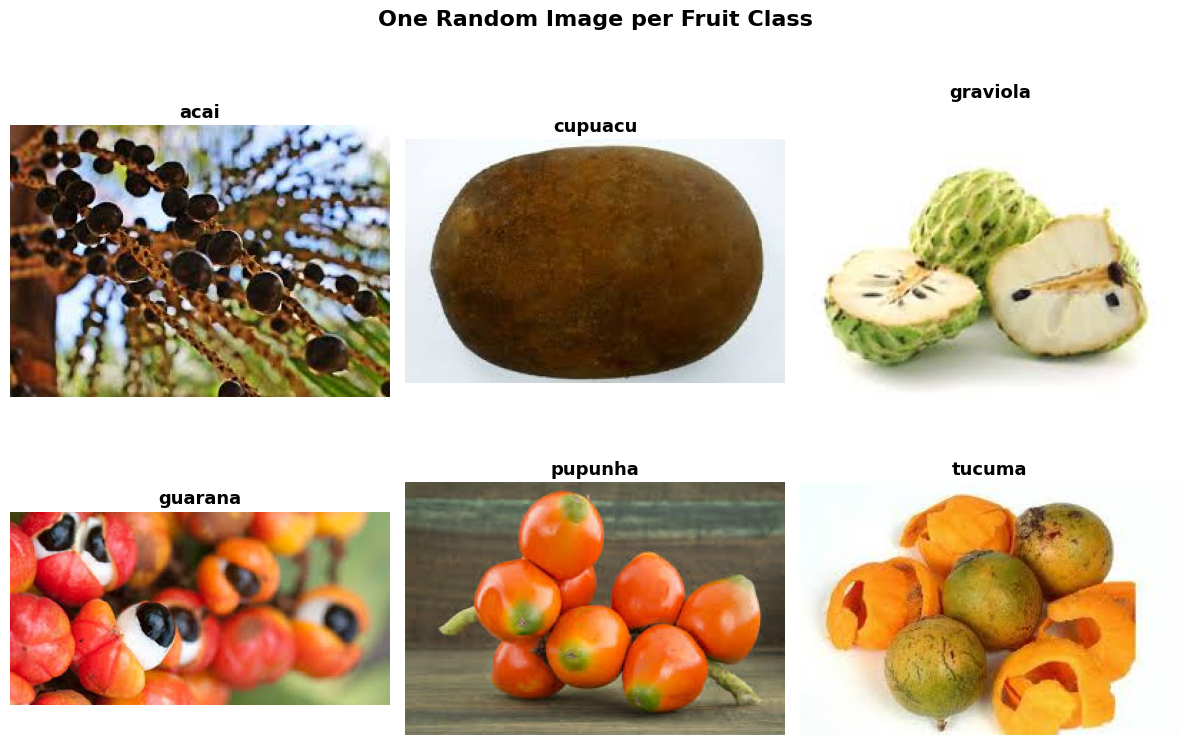


📌 Observation: The dataset contains 6 Amazon fruit classes.
   Images vary in background, lighting, and orientation — a good challenge for CNN!


In [5]:
# ─── CELL 5: Task 1.1 – Visualise One Image per Class ────────────────────────
class_dirs = sorted(os.listdir(TRAIN_DIR))
num_classes = len(class_dirs)

cols = 3
rows = (num_classes + cols - 1) // cols   # enough rows for all classes

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = axes.flatten()

for idx, cls in enumerate(class_dirs):
    cls_path = os.path.join(TRAIN_DIR, cls)
    images   = [f for f in os.listdir(cls_path)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    img_path = os.path.join(cls_path, random.choice(images))
    img      = mpimg.imread(img_path)
    axes[idx].imshow(img)
    axes[idx].set_title(cls, fontsize=13, fontweight='bold')
    axes[idx].axis('off')

# Hide unused subplots
for ax in axes[num_classes:]:
    ax.axis('off')

plt.suptitle('One Random Image per Fruit Class', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/task1_visualisation.png', bbox_inches='tight', dpi=150)
plt.show()
print("\n📌 Observation: The dataset contains 6 Amazon fruit classes.")
print("   Images vary in background, lighting, and orientation — a good challenge for CNN!")

In [6]:
# ─── CELL 6: Task 1.2 – Check for Corrupted Images ───────────────────────────
corrupted = []

for cls in class_dirs:
    cls_path = os.path.join(TRAIN_DIR, cls)
    for fname in os.listdir(cls_path):
        img_path = os.path.join(cls_path, fname)
        try:
            with Image.open(img_path) as img:
                img.verify()          # check file integrity
        except (IOError, SyntaxError):
            corrupted.append(img_path)
            os.remove(img_path)
            print(f"🗑️  Removed corrupted image: {img_path}")

if not corrupted:
    print("✅ No Corrupted Images Found.")
else:
    print(f"\n⚠️  Total corrupted images removed: {len(corrupted)}")

✅ No Corrupted Images Found.


---
## 📌 Task 2 – Loading and Preprocessing Image Data

In [7]:
# ─── CELL 7: Task 2 – Build Train / Validation / Test Datasets ───────────────
IMG_HEIGHT      = 128
IMG_WIDTH       = 128
BATCH_SIZE      = 16          # as required by Task 4
VALIDATION_SPLIT = 0.2        # 80/20 train-val split

# Rescaling layer (normalise pixels to [0, 1])
rescale = tf.keras.layers.Rescaling(1.0 / 255)

# ── Training dataset ──────────────────────────────────────────────────────────
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=VALIDATION_SPLIT,
    subset='training',
    seed=123
)
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# ── Validation dataset ────────────────────────────────────────────────────────
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False,
    validation_split=VALIDATION_SPLIT,
    subset='validation',
    seed=123
)
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# ── Test dataset ──────────────────────────────────────────────────────────────
if TEST_DIR:
    test_ds = tf.keras.preprocessing.image_dataset_from_directory(
        TEST_DIR,
        labels='inferred',
        label_mode='int',
        image_size=(IMG_HEIGHT, IMG_WIDTH),
        interpolation='nearest',
        batch_size=BATCH_SIZE,
        shuffle=False,
        seed=123
    )
    test_ds = test_ds.map(lambda x, y: (rescale(x), y))
else:
    # Use validation set as test set if no separate test folder
    test_ds = val_ds
    print("ℹ️  Using validation set as test set (no separate test folder found).")

# Cache and prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("\n✅ Datasets created successfully!")
print(f"   Image size  : {IMG_HEIGHT} x {IMG_WIDTH}")
print(f"   Batch size  : {BATCH_SIZE}")
print(f"   Classes     : {class_names}")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.

✅ Datasets created successfully!
   Image size  : 128 x 128
   Batch size  : 16
   Classes     : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


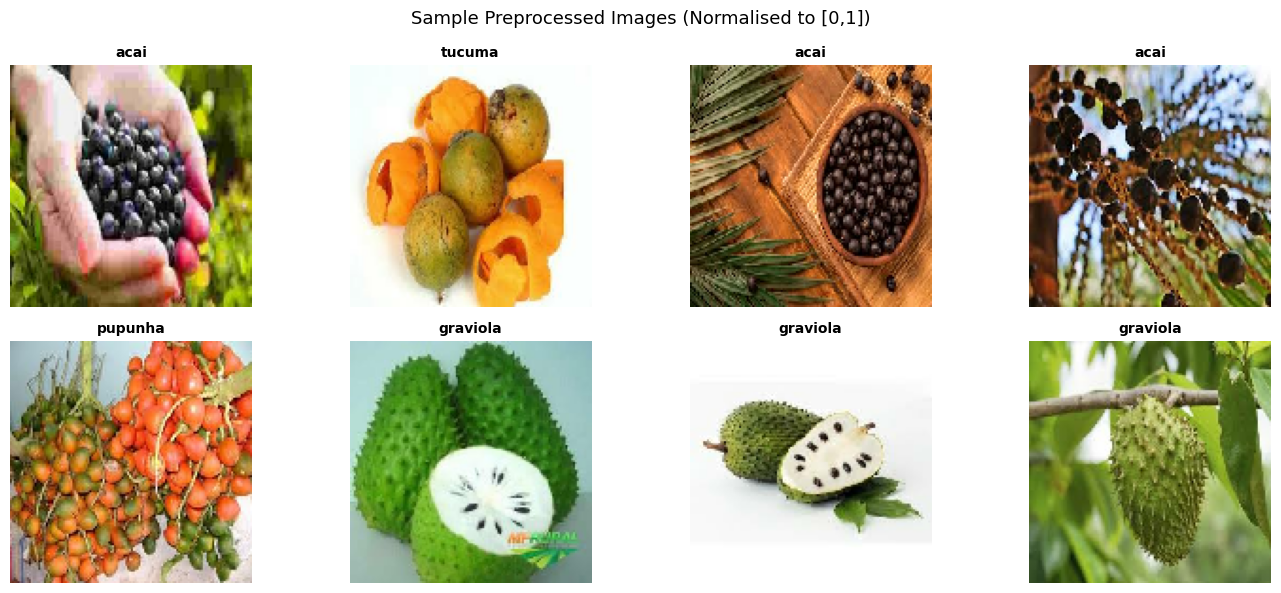

In [8]:
# ─── CELL 8: Visualise a Batch of Preprocessed Images ─────────────────────────
plt.figure(figsize=(14, 6))
for images, labels in train_ds.take(1):
    for i in range(min(8, len(images))):
        ax = plt.subplot(2, 4, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[labels[i]], fontsize=10, fontweight='bold')
        plt.axis('off')
plt.suptitle('Sample Preprocessed Images (Normalised to [0,1])', fontsize=13)
plt.tight_layout()
plt.show()

---
## 📌 Task 3 – Build the CNN Model

In [9]:
# ─── CELL 9: Task 3 – Define CNN Architecture (as per Worksheet spec) ─────────
#
# Architecture:
#   Conv2D(32, 3×3, same, relu) → MaxPool(2×2, stride 2)
#   Conv2D(32, 3×3, same, relu) → MaxPool(2×2, stride 2)
#   Flatten → Dense(128, relu) → Dense(64, relu) → Dense(num_classes, softmax)

def build_cnn(input_shape, num_classes):
    model = keras.Sequential([
        # ── Convolutional Block 1 ──────────────────────────────────────────────
        layers.Conv2D(filters=32, kernel_size=(3, 3), padding='same',
                      activation='relu', input_shape=input_shape,
                      name='conv2d_1'),
        layers.MaxPooling2D(pool_size=(2, 2), strides=2, name='maxpool_1'),

        # ── Convolutional Block 2 ──────────────────────────────────────────────
        layers.Conv2D(filters=32, kernel_size=(3, 3), padding='same',
                      activation='relu', name='conv2d_2'),
        layers.MaxPooling2D(pool_size=(2, 2), strides=2, name='maxpool_2'),

        # ── Fully Connected Network ────────────────────────────────────────────
        layers.Flatten(name='flatten'),
        layers.Dense(128, activation='relu', name='dense_128'),
        layers.Dense(64,  activation='relu', name='dense_64'),

        # ── Output Layer ──────────────────────────────────────────────────────
        layers.Dense(num_classes, activation='softmax', name='output')
    ], name='FruitCNN')
    return model

model = build_cnn(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), num_classes=NUM_CLASSES)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "FruitCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling2D)        │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling2D)        │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

---
## 📌 Task 4 – Compile and Train the Model

In [10]:
# ─── CELL 10: Task 4 – Compile the Model ──────────────────────────────────────
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("✅ Model compiled with Adam optimiser, sparse_categorical_crossentropy loss.")

✅ Model compiled with Adam optimiser, sparse_categorical_crossentropy loss.


In [11]:
# ─── CELL 11: Task 4 – Define Callbacks ───────────────────────────────────────
CHECKPOINT_PATH = '/content/best_fruit_cnn.h5'

checkpoint_cb = ModelCheckpoint(
    filepath=CHECKPOINT_PATH,
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop_cb = EarlyStopping(
    monitor='val_accuracy',
    patience=20,           # stop if no improvement for 20 epochs
    restore_best_weights=True,
    verbose=1
)

print("✅ Callbacks set:")
print(f"   ModelCheckpoint → saves best model to: {CHECKPOINT_PATH}")
print("   EarlyStopping   → patience=20 epochs on val_accuracy")

✅ Callbacks set:
   ModelCheckpoint → saves best model to: /content/best_fruit_cnn.h5
   EarlyStopping   → patience=20 epochs on val_accuracy


In [12]:
# ─── CELL 12: Task 4 – Train the Model ────────────────────────────────────────
EPOCHS = 250

print(f"🚀 Training started | max epochs: {EPOCHS} | batch size: {BATCH_SIZE}")
print("   (EarlyStopping will halt training early if validation accuracy plateaus)\n")

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=[checkpoint_cb, early_stop_cb],
    verbose=1
)

print("\n✅ Training complete!")

🚀 Training started | max epochs: 250 | batch size: 16
   (EarlyStopping will halt training early if validation accuracy plateaus)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 613ms/step - accuracy: 0.1066 - loss: 2.0447
Epoch 1: val_accuracy improved from None to 0.05556, saving model to /content/best_fruit_cnn.h5



Epoch 1: finished saving model to /content/best_fruit_cnn.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.0694 - loss: 2.1042 - val_accuracy: 0.0556 - val_loss: 2.4041
Epoch 2/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.1875 - loss: 1.8532
Epoch 2: val_accuracy improved from 0.05556 to 0.11111, saving model to /content/best_fruit_cnn.h5



Epoch 2: finished saving model to /content/best_fruit_cnn.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.4306 - loss: 1.6420 - val_accuracy: 0.1111 - val_loss: 1.7525
Epoch 3/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5625 - loss: 1.4668
Epoch 3: val_accuracy improved from 0.11111 to 0.27778, saving model to /content/best_fruit_cnn.h5



Epoch 3: finished saving model to /content/best_fruit_cnn.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5139 - loss: 1.3258 - val_accuracy: 0.2778 - val_loss: 1.6349
Epoch 4/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6250 - loss: 1.2208
Epoch 4: val_accuracy improved from 0.27778 to 0.55556, saving model to /content/best_fruit_cnn.h5



Epoch 4: finished saving model to /content/best_fruit_cnn.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.7500 - loss: 0.9651 - val_accuracy: 0.5556 - val_loss: 0.9470
Epoch 5/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7500 - loss: 0.7860
Epoch 5: val_accuracy improved from 0.55556 to 0.72222, saving model to /content/best_fruit_cnn.h5



Epoch 5: finished saving model to /content/best_fruit_cnn.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.8056 - loss: 0.6731 - val_accuracy: 0.7222 - val_loss: 0.9939
Epoch 6/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8125 - loss: 0.5222
Epoch 6: val_accuracy improved from 0.72222 to 0.83333, saving model to /content/best_fruit_cnn.h5



Epoch 6: finished saving model to /content/best_fruit_cnn.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9028 - loss: 0.3900 - val_accuracy: 0.8333 - val_loss: 0.4703
Epoch 7/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9375 - loss: 0.2600
Epoch 7: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9583 - loss: 0.2102 - val_accuracy: 0.7778 - val_loss: 0.7348
Epoch 8/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9375 - loss: 0.2184
Epoch 8: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9861 - loss: 0.1265 - val_accuracy: 0.8333 - val_loss: 0.2668
Epoch 9/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.1440
Epoch 9: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0760 - val_accuracy: 0.7222 - val_loss: 1.0457
Epoch 10/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6875 - loss:


Epoch 11: finished saving model to /content/best_fruit_cnn.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9028 - loss: 0.2877 - val_accuracy: 0.8889 - val_loss: 0.2083
Epoch 12/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8125 - loss: 0.1889
Epoch 12: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8750 - loss: 0.1897 - val_accuracy: 0.5556 - val_loss: 1.3377
Epoch 13/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9375 - loss: 0.1705
Epoch 13: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9028 - loss: 0.1969 - val_accuracy: 0.8333 - val_loss: 0.4130
Epoch 14/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0406
Epoch 14: val_accuracy improved from 0.88889 to 0.94444, saving model to /content/best_fruit_cnn.h5



Epoch 14: finished saving model to /content/best_fruit_cnn.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9861 - loss: 0.0513 - val_accuracy: 0.9444 - val_loss: 0.1415
Epoch 15/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 1.0000 - loss: 0.0739
Epoch 15: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0515 - val_accuracy: 0.9444 - val_loss: 0.1826
Epoch 16/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0340
Epoch 16: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0211 - val_accuracy: 0.8889 - val_loss: 0.2697
Epoch 17/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0068
Epoch 17: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0051 - val_accuracy: 0.8889 - val_loss: 0.3601
Epoch 18/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 1.0000 

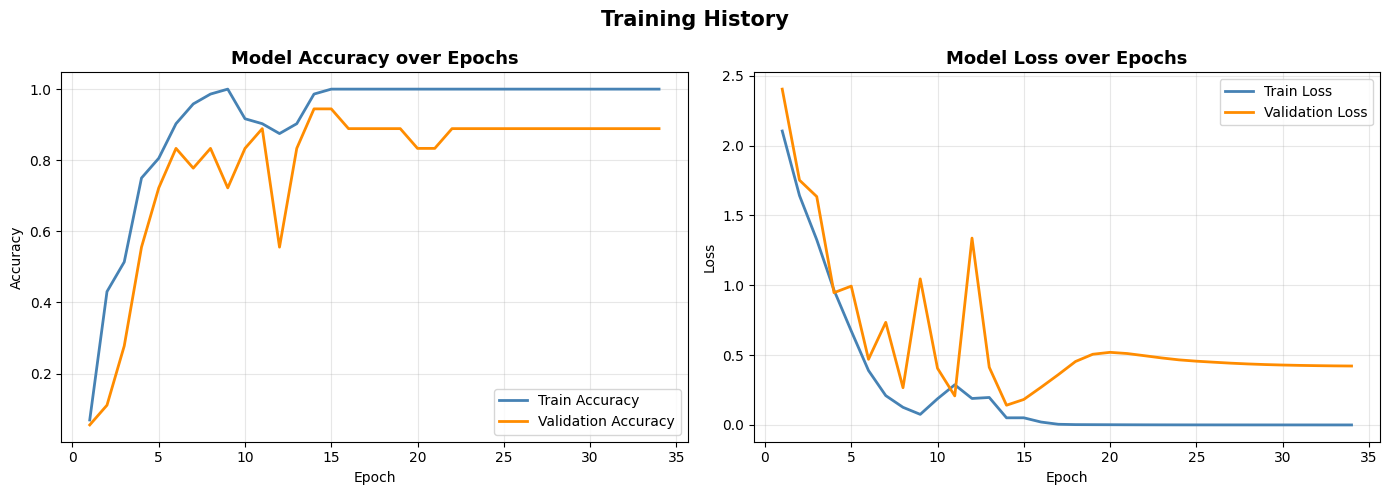

📊 Training curves saved to /content/training_curves.png


In [13]:
# ─── CELL 13: Training & Validation Curves ────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_ran = range(1, len(history.history['accuracy']) + 1)

# Accuracy
ax1.plot(epochs_ran, history.history['accuracy'],     label='Train Accuracy',      color='steelblue',  linewidth=2)
ax1.plot(epochs_ran, history.history['val_accuracy'], label='Validation Accuracy', color='darkorange', linewidth=2)
ax1.set_title('Model Accuracy over Epochs', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(epochs_ran, history.history['loss'],     label='Train Loss',      color='steelblue',  linewidth=2)
ax2.plot(epochs_ran, history.history['val_loss'], label='Validation Loss', color='darkorange', linewidth=2)
ax2.set_title('Model Loss over Epochs', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Training curves saved to /content/training_curves.png")

---
## 📌 Task 5 – Evaluate the Model

In [14]:
# ─── CELL 14: Task 5 – Evaluate on Test Set ───────────────────────────────────
print("🔍 Evaluating model on test set...")
test_loss, test_acc = model.evaluate(test_ds, verbose=1)

print("\n" + "="*40)
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print("="*40)

🔍 Evaluating model on test set...
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 708ms/step - accuracy: 0.6000 - loss: 0.7997

  Test Loss     : 0.7997
  Test Accuracy : 0.6000  (60.00%)


---
## 📌 Task 6 – Save and Load the Model

In [15]:
# ─── CELL 15: Task 6 – Save the Model ────────────────────────────────────────
SAVE_PATH = '/content/fruit_cnn_final.h5'
model.save(SAVE_PATH)
print(f"✅ Model saved to: {SAVE_PATH}")

✅ Model saved to: /content/fruit_cnn_final.h5


In [16]:
# ─── CELL 16: Task 6 – Load and Re-evaluate the Saved Model ──────────────────
loaded_model = keras.models.load_model(SAVE_PATH)
print("✅ Model loaded from disk.")

loaded_loss, loaded_acc = loaded_model.evaluate(test_ds, verbose=1)
print("\n" + "="*40)
print(f"  Loaded Model Test Loss     : {loaded_loss:.4f}")
print(f"  Loaded Model Test Accuracy : {loaded_acc:.4f}  ({loaded_acc*100:.2f}%)")
print("="*40)
print("\n✅ Results match → model saved and loaded correctly.")

✅ Model loaded from disk.
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 362ms/step - accuracy: 0.6000 - loss: 0.7997

  Loaded Model Test Loss     : 0.7997
  Loaded Model Test Accuracy : 0.6000  (60.00%)

✅ Results match → model saved and loaded correctly.


---
## 📌 Task 7 – Predictions and Classification Report

In [17]:
# ─── CELL 17: Task 7 – Generate Predictions ──────────────────────────────────
print("🔮 Generating predictions on test set...")

y_true = []
y_pred_probs = []

for images, labels in test_ds:
    probs = loaded_model.predict(images, verbose=0)
    y_pred_probs.extend(probs)
    y_true.extend(labels.numpy())

y_true  = np.array(y_true)
y_pred  = np.argmax(np.array(y_pred_probs), axis=1)

print(f"✅ Predictions done.  Samples: {len(y_true)}")

🔮 Generating predictions on test set...
✅ Predictions done.  Samples: 30


In [18]:
# ─── CELL 18: Task 7 – Classification Report ─────────────────────────────────
print("📋 Classification Report\n")
print("=" * 60)
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)
print("=" * 60)

📋 Classification Report

              precision    recall  f1-score   support

        acai       0.80      0.80      0.80         5
     cupuacu       1.00      0.20      0.33         5
    graviola       0.83      1.00      0.91         5
     guarana       1.00      0.40      0.57         5
     pupunha       0.50      0.20      0.29         5
      tucuma       0.36      1.00      0.53         5

    accuracy                           0.60        30
   macro avg       0.75      0.60      0.57        30
weighted avg       0.75      0.60      0.57        30



/tmp/ipykernel_3240/2268286884.py:19: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3240/2268286884.py:19: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3240/2268286884.py:20: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/sample_predictions.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_3240/2268286884.py:20: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/sample_predictions.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED C

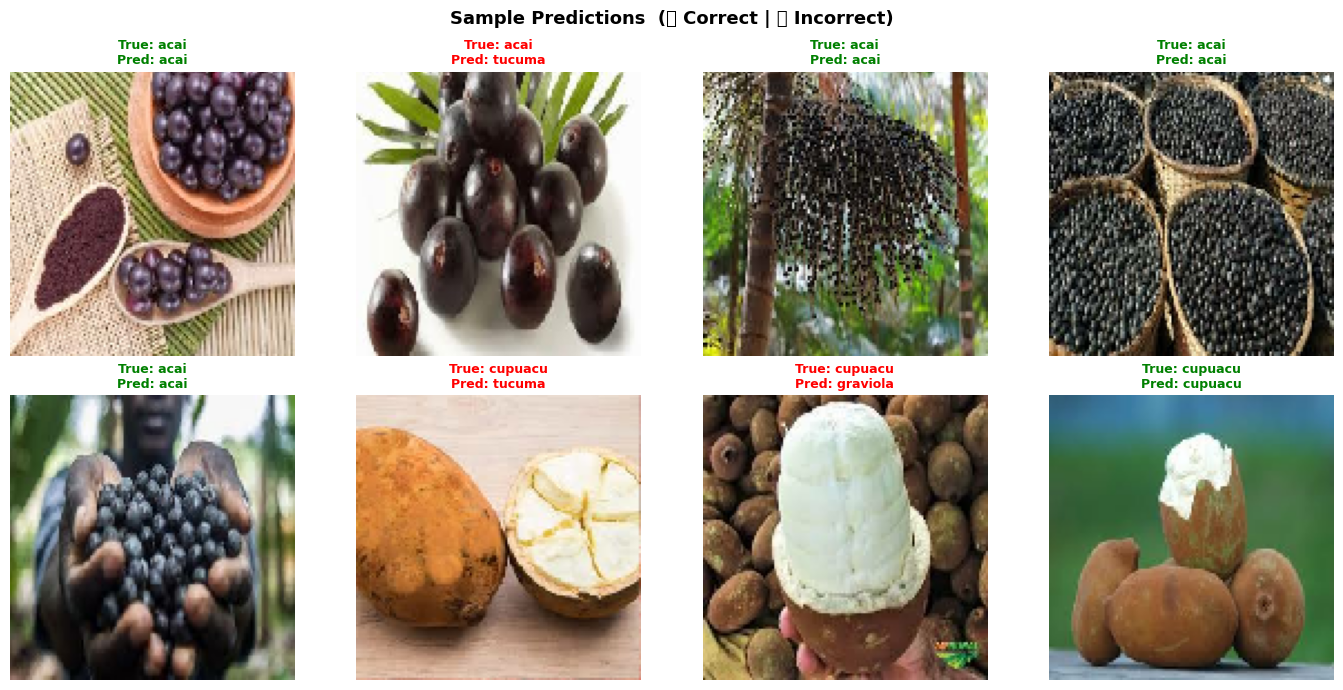

📊 Sample predictions saved to /content/sample_predictions.png


In [19]:
# ─── CELL 19: Task 7 – Visualise Sample Predictions ──────────────────────────
# Show 8 test images with predicted vs actual labels
sample_images, sample_labels = next(iter(test_ds))
sample_preds = np.argmax(loaded_model.predict(sample_images, verbose=0), axis=1)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i in range(min(8, len(sample_images))):
    axes[i].imshow(sample_images[i].numpy())
    true_label = class_names[sample_labels[i]]
    pred_label = class_names[sample_preds[i]]
    color      = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(f"True: {true_label}\nPred: {pred_label}",
                       color=color, fontsize=9, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Sample Predictions  (🟢 Correct | 🔴 Incorrect)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Sample predictions saved to /content/sample_predictions.png")